# The VIP Path
Tujuan : 

## 1. Overview
Tujuan : Melihat sekilas bentuk dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("dataset-pelanggan.csv")
df.head()

,Unnamed: 0,id_pelanggan,jam_main_mingguan,genre_favorit,pengeluaran_snack,waktu_main_utama,hardware_requirement,vip_lounge_visit,target_membership
0,0,1,23.10,FPS,22000,Subuh,1,1,0
1,1,2,4.43,Casual,37000,Sore,0,1,0
2,2,3,56.37,MOBA,22000,Subuh,1,16,0
3,3,4,31.96,RPG,18000,Sore,0,19,0
4,4,5,23.57,Casual,61000,Sore,1,4,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            1000 non-null   int64  
 1   id_pelanggan          1000 non-null   int64  
 2   jam_main_mingguan     1000 non-null   float64
 3   genre_favorit         1000 non-null   object 
 4   pengeluaran_snack     1000 non-null   int64  
 5   waktu_main_utama      1000 non-null   object 
 6   hardware_requirement  1000 non-null   int64  
 7   vip_lounge_visit      1000 non-null   int64  
 8   target_membership     1000 non-null   int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 70.4+ KB


In [3]:
df.tail()

,Unnamed: 0,id_pelanggan,jam_main_mingguan,genre_favorit,pengeluaran_snack,waktu_main_utama,hardware_requirement,vip_lounge_visit,target_membership
995,995,996,48.33,Casual,62000,Sore,0,15,0
996,996,997,45.62,MOBA,24000,Malam,0,19,0
997,997,998,42.26,MOBA,66000,Siang,1,6,0
998,998,999,52.68,FPS,77000,Siang,0,14,0
999,999,1000,56.83,RPG,69000,Sore,1,15,0


In [4]:
df.isnull().sum()

Unnamed: 0              0
id_pelanggan            0
jam_main_mingguan       0
genre_favorit           0
pengeluaran_snack       0
waktu_main_utama        0
hardware_requirement    0
vip_lounge_visit        0
target_membership       0
dtype: int64

## 2. Data Sanitization & Leakage Audit
Tujuan : Memastikan model belajar dari pola perilaku, bukan dari "jawaban yang bocor".

In [5]:
# Periksa korelasi antara vip_lounge_visit dengan target_membership
print("Korelasi: ", round(df["vip_lounge_visit"].corr(df["target_membership"]), 5))

Korelasi:  0.19192


Kedua variabel menunjukkan korelasi yang positif meski agak lemah. Namun, vip_lounge_visit telah memberi informasi bahwa pelanggan tersebut telah membership (pelanggan sering memasuki ruang vip karena sudah membership). Sehingga, vip_lounge_visit jangan digunakan dalam model.

## 3. Entropy & Information Gain
Tujuan: Menentukan variabel mana yang paling efisien membelah data menjadi grup yang "murni".

### 3.1 Entropy

In [6]:
# ENTROPY FUNCTION
def entropy(data_label):
    probs = data_label.value_counts(normalize=True)
    # Rumus: -sum(p * log2(p))
    return -np.sum([p * np.log2(p) for p in probs if p > 0])

entropy_awal = entropy(df["target_membership"])
print("Entropy Awal: ", entropy_awal)


Entropy Awal:  0.9149263727797274


### 3.2 Information Gain

#### 3.2.1 Genre

In [7]:
total_data = len(df)

gain_genre = entropy_awal


for genre in df["genre_favorit"].unique():
    subset = df[df["genre_favorit"] == genre]
    weight = len(subset) / total_data
    entropy_subset = entropy(subset["target_membership"])


    gain_genre -= (weight * entropy_subset)




#### 3.2.2 Hardware

In [8]:
gain_hardware = entropy_awal

for hardware in df["hardware_requirement"].unique():
    subset = df[df["hardware_requirement"] == hardware]
    weight = len(subset) / total_data
    entropy_subset = entropy(subset["target_membership"])


    gain_hardware -= (weight * entropy_subset)




#### 3.2.3 Waktu Main Utama

In [9]:
gain_waktu_main = entropy_awal

for waktu in df["waktu_main_utama"].unique():
    subset = df[df["waktu_main_utama"] == waktu]
    weight = len(subset) / total_data
    entropy_subset = entropy(subset["target_membership"])


    gain_waktu_main -= (weight * entropy_subset)




#### 3.2.4 Pengeluaran Snack

In [10]:
gain_pengeluaran = entropy_awal

for pengeluaran in df["pengeluaran_snack"].unique():
    subset = df[df["pengeluaran_snack"] == pengeluaran]
    weight = len(subset) / total_data
    entropy_subset = entropy(subset["target_membership"])


    gain_pengeluaran -= (weight * entropy_subset)



#### 3.2.5 Jam Main Mingguan
Note : Karena sifat variabel yang kontinu (angka), maka perlu mencari batas terbaik.

In [11]:
threshold = 34

grup_atas = df[df['jam_main_mingguan'] > threshold]
grup_bawah = df[df['jam_main_mingguan'] <= threshold]

weight_atas = len(grup_atas) / total_data
weight_bawah = len(grup_bawah) / total_data

ent_atas = entropy(grup_atas['target_membership'])
ent_bawah = entropy(grup_bawah['target_membership'])

gain_jam_mingguan = entropy_awal - (weight_atas * ent_atas + weight_bawah * ent_bawah)

Setelah dicari dan dicoba, gain tertinggi terdapat pada batas angka 34.

#### 3.2.5 Finale Compare

In [12]:
print("Gain Genre: ", gain_genre)
print("Gain Hardware: ", gain_hardware)
print("Gain Waktu Main: ", gain_waktu_main)
print("Gain Pengeluaran Snack: ", gain_pengeluaran)
print("Gain Jam Main Mingguan (TP = 34 Jam): ", gain_jam_mingguan )

Gain Genre:  0.011392198537709092
Gain Hardware:  0.00780437186090388
Gain Waktu Main:  0.030675814608435728
Gain Pengeluaran Snack:  0.09525760707023703
Gain Jam Main Mingguan (TP = 34 Jam):  0.06610792211958638


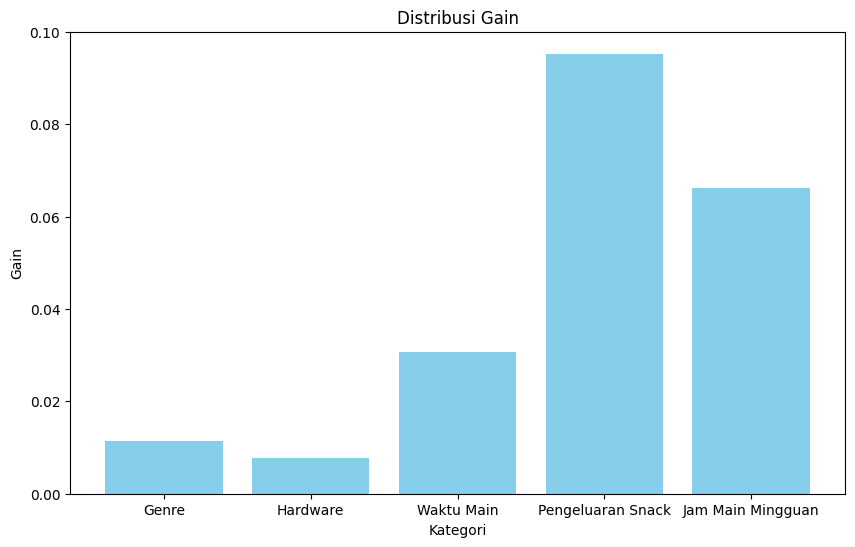

In [25]:
category = ["Genre", "Hardware", "Waktu Main", "Pengeluaran Snack", "Jam Main Mingguan"]
gain_values = [gain_genre, gain_hardware, gain_waktu_main, gain_pengeluaran, gain_jam_mingguan]

plt.figure(figsize=(10, 6))
plt.bar(category, gain_values, color="skyblue")

plt.xlabel("Kategori")
plt.xticks(fontsize=10)
plt.ylabel("Gain")
plt.title("Distribusi Gain")

plt.show()

Dari analisis dan perbandingan tersebut, bisa dilihat bahwa pengeluaran snack memiliki information gain paling tinggi diantara variabel lain. Sehingga dapat disimpulkan bahwa variabel terkuat untuk mengatasi kekacauan data adalah pengeluaran_snack.

## 4. Laplace Smoothing
Tujuan: Mencegah model menjadi terlalu "yakin" pada data yang jumlah sampelnya sangat sedikit.

### 4.1 Kombinasi Langka

In [ ]:
# Cari kombinasi langka
# Cek kombinasi Genre dan Waktu Main
kelompok_langka = df.groupby(['genre_favorit', 'waktu_main_utama']).size().reset_index(name='jumlah_orang')

print(kelompok_langka.sort_values('jumlah_orang').head(5))

   genre_favorit waktu_main_utama  jumlah_orang
16           RPG             Pagi            13
17           RPG            Siang            34
10          MOBA            Malam            38
18           RPG             Sore            39
1         Casual             Pagi            41


Dalam data, kombinasi paling langka antara variabel genre_favorit dan waktu_main_utama adalah player RPG yang bermain pada pagi hari.

In [ ]:
grup_langka = df[(df["genre_favorit"] == "RPG") & (df["waktu_main_utama"] == "Pagi")]

jumlah_member = grup_langka["target_membership"].value_counts()
print("Jumlah Member dalam Grup Langka: ", jumlah_member)

jumlah_member = jumlah_member.get(1, 0) # Ambil yang labelnya 1, kalau gak ada beri 0
jumlah_total = len(grup_langka)

print(f"\nMember: {jumlah_member}")
print(f"Total Orang: {jumlah_total}")

Jumlah Member dalam Grup Langka:  target_membership
0    13
Name: count, dtype: int64

Member: 0
Total Orang: 13


Menunjukkan bahwa 13 total orang dalam grup langka ini tidak termasuk member.

### 4.2 Simulasi Laplace

In [32]:
# peluang member
peluang_biasa = (jumlah_member / jumlah_total) * 100
print("Peluang Member (Biasa): ", peluang_biasa, "%")

Peluang Member (Biasa):  0.0 %


In [35]:
peluang_laplace = ((jumlah_member + 1) / (jumlah_total + 2) * 100)
print("Peluang Member (Laplace): ", round(peluang_laplace, 2), "%")

Peluang Member (Laplace):  6.67 %


Meskipun secara data mentah grup RPG Pagi punya konversi member sebesar 0%, namun dengan Laplace Smoothing kita mengoreksinya menjadi 6.67% untuk menghindari over-optimisme akibat sampel yang kecil. Tujuan simulasi ini adalah agar model tidak terlalu percaya 100% bahwa user atau pelanggan akan member atau tidak. Kenaikan ke angka 6.67% terlihat lebih konservatif dan aman untuk keputusan bisnis.